# Introduction

Welcome to the hands-on Colab notebook for TabPFN!

This install the online version of TabPFN using our web client. If you would like to access the offline version use: https://tinyurl.com/tabpfn-colab-local

**Installation**
* First, copy the notebook to be able to modify it.
* Then, run the cells in the installation block, this should
be good enough!

**API Registration**
* See the cell below to go through the registration process to use the pre-release TabPFN API for free.

---

> 🔵 **Hint** <br>
We recommend first enabling the **Table of Contents** with the `☰` icon in the top left and collapsing all sections by selecting all cells `Ctrl + Shift + A` and then pressing `Ctrl + ]`.

---

Thank you to [Lennart Purucker](https://github.com/LennartPurucker) for providing the original version of this notebook!

# Installation

The following cell installs a client that interacts with our pre-release API for the new version of TabPFN. This way, no GPU is required.

Restart your runtime and rerun the *cell*, if Colab asks for it.

In [1]:
# Install sklearn
!pip install scikit-learn==1.5.2

# Install TabPFN API Client
!pip install tabpfn-client

# TabPFN Extensions installs optional functionalities around the TabPFN model
# These include post-hoc ensembles, interpretability tools, and more
!git clone https://github.com/PriorLabs/tabpfn-extensions
!pip install -e tabpfn-extensions
!pip install tabpfn # TabPFN, currently required by tabpfn-extensions, but not basic usage


# Install Baselines
!pip install catboost xgboost

# Install example datasets
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 69.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 58.1 MB/s eta 0:00:00
Cloning into 'tabpfn-extensions'...
remote: Enumerating objects: 2089, done.
remote: Counting objects: 100% (288/288), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 2089 (delta 209), reused 175 (delta 175), pack-reused 1801 (from 2)
Receiving objects: 100% (2089/2089), 775.16 KiB | 16.49 MiB/s, done.
Resolving deltas: 100% (1273/1273), done.
Obtaining file:///content/tabpfn-extensions
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128

**Now Restart the Runtime**

# Necessary Imports for the Notebook

The examples in this notebook require the following imports.
Make sure to run this cell before any other cell.




In [2]:
pip install skfeature-chappers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 kB 6.5 MB/s eta 0:00:00


In [ ]:
#pip install nanopq

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#from nanopq import PQ  # Make sure you have nanopq installed: pip install nanopq
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
from skfeature.function.information_theoretical_based import CMIM, JMI
import gc
import time
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score
from tabpfn import TabPFNClassifier

In [4]:
import scipy.spatial as ss
from scipy.special import digamma
from math import log
import numpy.random as nr
import numpy as np
import random
def hist(sx):
    # Histogram from list of samples
    d = dict()
    for s in sx:
        d[s] = d.get(s, 0) + 1

    return map(lambda z: float(z)/len(sx), d.values())

def elog(x):
    # for entropy, 0 log 0 = 0. but we get an error for putting log 0
    if x <= 0. or x >= 1.:
        return 0
    else:
        return x*log(x)

def cmidd(x, y, z):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return entropyd(list(zip(y, z)))+entropyd(list(zip(x, z)))-entropyd(list(zip(x, y, z)))-entropyd(z)

# Discrete estimators
def entropyd(sx, base=2):
    """
    Discrete entropy estimator given a list of samples which can be any hashable object
    """

    return entropyfromprobs(hist(sx), base=base)

def entropyfromprobs(probs, base=2):
    # Turn a normalized list of probabilities of discrete outcomes into entropy (base 2)
    return -sum(map(elog, probs))/log(base)

def midd(x, y):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return -entropyd(list(zip(x, y)))+entropyd(x)+entropyd(y)

In [5]:
import numpy as np
from math import log

def hist(sx):
    # Histogram from list of samples
    d = dict()
    for s in sx:
        d[s] = d.get(s, 0) + 1

    return map(lambda z: float(z)/len(sx), d.values())

def elog(x):
    # for entropy, 0 log 0 = 0. but we get an error for putting log 0
    if x <= 0. or x >= 1.:
        return 0
    else:
        return x*log(x)

def cmidd(x, y, z):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return entropyd(list(zip(y, z)))+entropyd(list(zip(x, z)))-entropyd(list(zip(x, y, z)))-entropyd(z)

# Discrete estimators
def entropyd(sx, base=2):
    """
    Discrete entropy estimator given a list of samples which can be any hashable object
    """

    return entropyfromprobs(hist(sx), base=base)

def entropyfromprobs(probs, base=2):
    # Turn a normalized list of probabilities of discrete outcomes into entropy (base 2)
    return -sum(map(elog, probs))/log(base)

def midd(x, y):
    """
    Discrete mutual information estimator given a list of samples which can be any hashable object
    """

    return -entropyd(list(zip(x, y)))+entropyd(x)+entropyd(y)

def fast_cmim(X, y, **kwargs):
    """
    This function implements the CMIM feature selection.
    Input
    -----
    X: {numpy array}, shape (n_samples, n_features)
        Input data, guaranteed to be a discrete numpy array
    y: {numpy array}, shape (n_samples,)
        guaranteed to be a numpy array
    kwargs: {dictionary}
        n_selected_features: {int}
            number of features to select
    Output
    ------
    F: {numpy array}, shape (n_features,)
        index of selected features, F[0] is the most important feature
    t1: {numpy array}, shape: (n_features,)
        minimal corresponding mutual information between selected features and response when
        conditionned on a previously selected feature
    Reference
    ---------
    Fleuret 2004 - Fast Binary Feature Selection with Conditional Mutual Information
    http://www.idiap.ch/~fleuret/papers/fleuret-jmlr2004.pdf
    """

    n_samples, n_features = X.shape
    is_n_selected_features_specified = False

    if 'n_selected_features' in kwargs.keys():
        n_selected_features = kwargs['n_selected_features']
        is_n_selected_features_specified = True
        F = np.nan * np.zeros(n_selected_features)
    else:
        F = np.nan * np.zeros(n_features)

    # t1
    t1 = np.zeros(n_features)

    # m is a counting indicator
    m = np.zeros(n_features) - 1

    for i in range(n_features):
        f = X[:, i]
        t1[i] = midd(f, y)


    for k in range(n_features):
        ### uncomment to keep track
        # counter = int(np.sum(~np.isnan(F)))
        # if counter%5 == 0 or counter <= 1:
        #     print("F contains %s features"%(counter))
        if k == 0:
            # select the feature whose mutual information is the largest
            idx = np.argmax(t1)
            F[0] = idx
            f_select = X[:, idx]

        if is_n_selected_features_specified:
            if np.sum(~np.isnan(F)) == n_selected_features:
                break

        sstar = -1000000 # start with really low value for best partial score sstar
        for i in range(n_features):

            if i not in F:

                while (t1[i] > sstar) and (m[i]<k-1) :
                    m[i] = m[i] + 1
                    t1[i] = min(t1[i], cmidd(X[:,i], # feature i
                                             y,  # target
                                             X[:, int(F[int(m[i])])] # conditionned on selected features
                                            )
                               )
                if t1[i] > sstar:
                    sstar = t1[i]
                    F[k+1] = i

    F = np.array(F[F>-100])
    F = F.astype(int)
    t1 = t1[F]
    return (F, t1)

# **Reading CSV file**

In [6]:
# Load data
data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-Malgenome.csv")
#data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-CIC-2020.csv")
X = data.iloc[:, :-1].values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)

In [ ]:
data

,transact,bindService,onServiceConnected,ServiceConnection,android.os.Binder,READ_SMS,attachInterface,WRITE_SMS,TelephonyManager.getSubscriberId,Ljava.lang.Class.getCanonicalName,...,Ljava.lang.Object.getClass,SET_ORIENTATION,DEVICE_POWER,EXPAND_STATUS_BAR,GET_TASKS,GLOBAL_SEARCH,GET_PACKAGE_SIZE,SET_PREFERRED_APPLICATIONS,android.intent.action.PACKAGE_CHANGED,Class
0,0,0,0,0,0,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0,0,0,0,0,1,0,0,1,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0,0,0,0,0,1,0,1,1,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,1,1,1,1,1,1,1,1,1,1,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2407,0,0,0,0,1,0,0,0,0,0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2408,0,0,1,0,0,0,0,0,0,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2409,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2410,1,0,0,0,1,0,1,0,0,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)

In [ ]:
# record start time
start = time.time()
#f, t, p = JMI.jmi(X_train,y_train, n_selected_features = 5)
f = JMI.jmi(X_train, y_train, n_selected_features=100 )
end = time.time()

# print the difference between start
# and end time in milli. secs
print("The time of execution of above program is :",
      (end-start), "sec")

The time of execution of above program is : 79.10096621513367 sec


In [ ]:
f

array([213, 201, 214, 209, 206, 212, 203, 208, 211, 205, 207, 210, 190,
       194, 204, 198, 200, 199, 202, 195, 189, 197, 178, 196, 183, 191,
       192, 185, 193, 184, 186, 187, 168, 188, 169, 180, 182, 181, 155,
       177, 179, 165, 176, 154, 124, 171, 172, 174, 173, 162, 150, 175,
       170,  94, 167, 158, 113, 135, 156, 163, 141, 159, 164, 140, 160,
       166, 145, 152,  59,  13,  53, 132, 147, 102, 153, 161,  26, 157,
       146, 148, 142, 131, 151, 111, 143, 149, 123, 119, 134, 129, 136,
       133, 138,  68, 127,  69,  27, 144, 114, 125,  24, 103,  65,  70,
        86,  72,   4,  60,  16,  11, 116, 120,  66,  44,  85,  99,  73,
       122,  82,   0,  55,  88,  15,  54,  21,  96,  30,  48,  22,  92,
        33,  42, 126, 106,  83,  57,  89,   2,   3,  84,  25,  81,  14,
        58,  93,  46, 139,  38,  47, 117,  40,  78,  36,  56,  29, 108,
         5, 128,  75, 107, 137,  41,  91,  90,  52, 118,  63,  76,  17,
       115,  20,  45,   9,  35,  62, 100,  37, 105,  71,  98,  7

In [7]:
f = [213, 201, 214, 209, 206, 212, 203, 208, 211, 205, 207, 210, 190,
       194, 204, 198, 200, 199, 202, 195, 189, 197, 178, 196, 183, 191,
       192, 185, 193, 184, 186, 187, 168, 188, 169, 180, 182, 181, 155,
       177, 179, 165, 176, 154, 124, 171, 172, 174, 173, 162, 150, 175,
       170,  94, 167, 158, 113, 135, 156, 163, 141, 159, 164, 140, 160,
       166, 145, 152,  59,  13,  53, 132, 147, 102, 153, 161,  26, 157,
       146, 148, 142, 131, 151, 111, 143, 149, 123, 119, 134, 129, 136,
       133, 138,  68, 127,  69,  27, 144, 114, 125,  24, 103,  65,  70,
        86,  72,   4,  60,  16,  11, 116, 120,  66,  44,  85,  99,  73,
       122,  82,   0,  55,  88,  15,  54,  21,  96,  30,  48,  22,  92,
        33,  42, 126, 106,  83,  57,  89,   2,   3,  84,  25,  81,  14,
        58,  93,  46, 139,  38,  47, 117,  40,  78,  36,  56,  29, 108,
         5, 128,  75, 107, 137,  41,  91,  90,  52, 118,  63,  76,  17,
       115,  20,  45,   9,  35,  62, 100,  37, 105,  71,  98,  77,  74,
        51,  61,  49,  64, 104,   7,  12, 121,  87, 112,  10,  18,  28,
        19, 101,   8,   6,  32,  50, 110,   1,  80,  23,  67,  43,  31,
        34,  95, 130, 109,  97,  79,  39]

In [8]:
f = np.array(f[:100])
f

array([213, 201, 214, 209, 206, 212, 203, 208, 211, 205, 207, 210, 190,
       194, 204, 198, 200, 199, 202, 195, 189, 197, 178, 196, 183, 191,
       192, 185, 193, 184, 186, 187, 168, 188, 169, 180, 182, 181, 155,
       177, 179, 165, 176, 154, 124, 171, 172, 174, 173, 162, 150, 175,
       170,  94, 167, 158, 113, 135, 156, 163, 141, 159, 164, 140, 160,
       166, 145, 152,  59,  13,  53, 132, 147, 102, 153, 161,  26, 157,
       146, 148, 142, 131, 151, 111, 143, 149, 123, 119, 134, 129, 136,
       133, 138,  68, 127,  69,  27, 144, 114, 125])

In [9]:
selected_features_names=[]
for i in range(len(f)):
    selected_features_names.append(data.columns[f[i]])
selected_features_names

['SET_PREFERRED_APPLICATIONS',
 'Ljavax.crypto.Cipher',
 'android.intent.action.PACKAGE_CHANGED',
 'EXPAND_STATUS_BAR',
 'Ljava.lang.Object.getClass',
 'GET_PACKAGE_SIZE',
 'android.intent.action.PACKAGE_RESTARTED',
 'DEVICE_POWER',
 'GLOBAL_SEARCH',
 'READ_EXTERNAL_STORAGE',
 'SET_ORIENTATION',
 'GET_TASKS',
 'BROADCAST_SMS',
 'TelephonyManager.getSimOperator',
 'READ_INPUT_STATE',
 'sendMultipartTextMessage',
 'STATUS_BAR',
 'BIND_VPN_SERVICE',
 'MODIFY_PHONE_STATE',
 'WRITE_EXTERNAL_STORAGE',
 'CHANGE_CONFIGURATION',
 'android.intent.action.REBOOT',
 'BROADCAST_WAP_PUSH',
 'android.intent.action.CAMERA_BUTTON',
 'ADD_VOICEMAIL',
 'BIND_WALLPAPER',
 'BROADCAST_PACKAGE_REMOVED',
 'SET_ACTIVITY_WATCHER',
 'TelephonyManager.isNetworkRoaming',
 'INSTALL_LOCATION_PROVIDER',
 'TelephonyManager.getCallState',
 'VIBRATE',
 'android.content.pm.PackageInfo',
 'Runtime.getRuntime',
 'BIND_ACCESSIBILITY_SERVICE',
 'INJECT_EVENTS',
 'SET_PROCESS_LIMIT',
 'ACCESS_SURFACE_FLINGER',
 'KeySpec',
 'an

In [10]:
len(selected_features_names)

100

# find the highest accuracy with respect to different number of features

In [ ]:
from tabpfn import TabPFNClassifier

tab_pfn_={
    "acc":{"index":[],"val":[],},
    "per":{"index":[],"val":[],},
    "rec":{"index":[],"val":[],},
    "f1s":{"index":[],"val":[],},
    "auc":{"index":[],"val":[],},
}

data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-Malgenome.csv")
for i in range(2,len(selected_features_names)+1):
    X = data[selected_features_names[:i]].values  # Features
    y = data.iloc[:, -1].values   # Binary labels (0 or 1)
    #start = time.time()
    #pq_pq = PQ(M=int(i/2), Ks=2)
    #pq_pq.fit(X.astype(np.float32))
    #codes_pq = pq_pq.encode(X.astype(np.float32))
    #end = time.time()

    # print the difference between start
    # and end time in milli. secs
    #print("The time of execution of above program is :", (end-start), "sec")
    X_train, X_test, y_train, y_test = train_test_split(X,y ,
                                   random_state=2,
                                   test_size=0.2,
                                   shuffle=True)
    # Initialize a classifier
    clf = TabPFNClassifier()
    start = time.time()
    clf.fit(X_train, y_train)
    end = time.time()
    print("The time of execution of training the tabpfn is :",
          (end-start), "sec")
    # Predict labels
    start = time.time()
    y_pred = clf.predict(X_test)
    end = time.time()
    print("The time of execution of testing sample with the tabpfn is :",
          ((end-start)/len(X_test)), "sec")
    tab_pfn_["acc"]['val'].append(accuracy_score(y_test, y_pred))
    tab_pfn_["acc"]['index'].append(i)
    tab_pfn_["per"]['val'].append(precision_score(y_test, y_pred))
    tab_pfn_["per"]['index'].append(i)
    tab_pfn_["rec"]['val'].append(recall_score(y_test, y_pred))
    tab_pfn_["rec"]['index'].append(i)
    tab_pfn_["f1s"]['val'].append(f1_score(y_test, y_pred))
    tab_pfn_["f1s"]['index'].append(i)

    y_prob = clf.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    tab_pfn_["auc"]['val'].append(auc(fpr, tpr))
    tab_pfn_["auc"]['index'].append(i)

The time of execution of training the tabpfn is : 51.57490539550781 sec
The time of execution of testing sample with the tabpfn is : 0.0006557444887837087 sec
The time of execution of training the tabpfn is : 48.85688829421997 sec
The time of execution of testing sample with the tabpfn is : 0.0007398801995074655 sec
The time of execution of training the tabpfn is : 46.580498456954956 sec
The time of execution of testing sample with the tabpfn is : 0.000856452804850781 sec
The time of execution of training the tabpfn is : 36.30863332748413 sec
The time of execution of testing sample with the tabpfn is : 0.0008874530867328794 sec
The time of execution of training the tabpfn is : 34.50530791282654 sec
The time of execution of testing sample with the tabpfn is : 0.0010107077482178455 sec
The time of execution of training the tabpfn is : 34.99210548400879 sec
The time of execution of testing sample with the tabpfn is : 0.0010729915513767031 sec
The time of execution of training the tabpfn i

In [ ]:
print("the highest accuracy where the number of features is: ", tab_pfn_["acc"]['index'][tab_pfn_["acc"]['val'].index(max(tab_pfn_["acc"]['val']))])
print("the highest accuracy value is: ", tab_pfn_["acc"]['val'][tab_pfn_["acc"]['val'].index(max(tab_pfn_["acc"]['val']))])
print("the highest AUC where the number of features is: ", tab_pfn_["auc"]['index'][tab_pfn_["auc"]['val'].index(max(tab_pfn_["auc"]['val']))])
print("the highest AUC value is: ", tab_pfn_["auc"]['val'][tab_pfn_["auc"]['val'].index(max(tab_pfn_["auc"]['val']))])
print("the highest precision where the number of features is: ", tab_pfn_["per"]['index'][tab_pfn_["per"]['val'].index(max(tab_pfn_['per']['val']))])
print("the highest precision value is: ", tab_pfn_["per"]['val'][tab_pfn_["per"]['val'].index(max(tab_pfn_['per']['val']))])
print("the highest recall where the number of features is: ", tab_pfn_["rec"]['index'][tab_pfn_["rec"]['val'].index(max(tab_pfn_["rec"]['val']))])
print("the highest recall value is: ", tab_pfn_["rec"]['val'][tab_pfn_["rec"]['val'].index(max(tab_pfn_["rec"]['val']))])
print("the highest f1_score where the number of features is: ", tab_pfn_["f1s"]['index'][tab_pfn_["f1s"]['val'].index(max(tab_pfn_["f1s"]['val']))])
print("the highest f1_score value is: ", tab_pfn_["f1s"]['val'][tab_pfn_["f1s"]['val'].index(max(tab_pfn_["f1s"]['val']))])

the highest accuracy where the number of features is:  100
the highest accuracy value is:  0.9635826771653543
the highest AUC where the number of features is:  98
the highest AUC value is:  0.9953309445142476
the highest precision where the number of features is:  96
the highest precision value is:  0.9918533604887984
the highest recall where the number of features is:  100
the highest recall value is:  0.9444444444444444
the highest f1_score where the number of features is:  100
the highest f1_score value is:  0.9638318670576735


In [ ]:
tab_pfn_["auc"]['val'][tab_pfn_["acc"]['val'].index(max(tab_pfn_["acc"]['val']))]

np.float64(0.9950400980346534)

In [ ]:
tab_pfn_['acc']['val'][98] #100 features

0.9635826771653543

In [ ]:
tab_pfn_['auc']['val'][98] #100 features

np.float64(0.9950400980346534)

In [ ]:
tab_pfn_['per']['val'][98] #100 features

np.float64(0.9840319361277445)

In [ ]:
tab_pfn_['rec']['val'][98] #100 features

np.float64(0.9444444444444444)

In [ ]:
tab_pfn_['f1s']['val'][98] #100 features

np.float64(0.9638318670576735)

In [ ]:
tab_pfn_

{'acc': {'index': [2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   94,
   95,
   96,
   97,
   98,
   99,
   100],
  'val': [0.4970472440944882,
   0.5019685039370079,
   0.5019685039370079,
   0.5364173228346457,
   0.5383858267716536,
   0.5433070866141733,
   0.5393700787401575,
   0.5482283464566929,
   0.6043307086614174,
   0.6043307086614174,
   0.6161417322834646,
   0.6181102362204725,
   0.638779527

In [ ]:
tab_pfn_['acc']['val']

[0.4970472440944882,
 0.5019685039370079,
 0.5019685039370079,
 0.5364173228346457,
 0.5383858267716536,
 0.5433070866141733,
 0.5393700787401575,
 0.5482283464566929,
 0.6043307086614174,
 0.6043307086614174,
 0.6161417322834646,
 0.6181102362204725,
 0.6387795275590551,
 0.640748031496063,
 0.656496062992126,
 0.65748031496063,
 0.655511811023622,
 0.6653543307086615,
 0.6751968503937008,
 0.6801181102362205,
 0.6801181102362205,
 0.6801181102362205,
 0.6811023622047244,
 0.6801181102362205,
 0.6889763779527559,
 0.687992125984252,
 0.687992125984252,
 0.718503937007874,
 0.719488188976378,
 0.7253937007874016,
 0.797244094488189,
 0.8198818897637795,
 0.8494094488188977,
 0.8375984251968503,
 0.8503937007874016,
 0.8484251968503937,
 0.8503937007874016,
 0.8454724409448819,
 0.8543307086614174,
 0.8513779527559056,
 0.8543307086614174,
 0.84251968503937,
 0.8494094488188977,
 0.8553149606299213,
 0.8533464566929134,
 0.8622047244094488,
 0.8572834645669292,
 0.860236220472441,
 0.85

In [ ]:
tab_pfn_["rec"]['val']

[np.float64(0.46551724137931033),
 np.float64(0.46360153256704983),
 np.float64(0.46551724137931033),
 np.float64(0.3773946360153257),
 np.float64(0.3773946360153257),
 np.float64(0.38697318007662834),
 np.float64(0.39080459770114945),
 np.float64(0.39080459770114945),
 np.float64(0.5478927203065134),
 np.float64(0.5478927203065134),
 np.float64(0.5440613026819924),
 np.float64(0.5440613026819924),
 np.float64(0.524904214559387),
 np.float64(0.5306513409961686),
 np.float64(0.5593869731800766),
 np.float64(0.5593869731800766),
 np.float64(0.5593869731800766),
 np.float64(0.5670498084291188),
 np.float64(0.60727969348659),
 np.float64(0.6168582375478927),
 np.float64(0.6168582375478927),
 np.float64(0.6168582375478927),
 np.float64(0.6168582375478927),
 np.float64(0.6111111111111112),
 np.float64(0.6245210727969349),
 np.float64(0.6226053639846744),
 np.float64(0.6206896551724138),
 np.float64(0.5957854406130269),
 np.float64(0.5881226053639846),
 np.float64(0.5957854406130269),
 np.flo

# find the average accuracy with respect to the best accuracy gained by 100 features

In [12]:
from tabpfn import TabPFNClassifier
import tracemalloc

tab_pfn_max={
    "acc":{"fold":[],"val":[],},
    "per":{"fold":[],"val":[],},
    "rec":{"fold":[],"val":[],},
    "f1s":{"fold":[],"val":[],},
    "auc":{"fold":[],"val":[],},
}

memory = {
    "current":[],
    "peak":[]
}

train_time=[]
test_time=[]

data = pd.read_csv("/content/sample_data/features_outlier_handler_norm_two_classes_only-Malgenome.csv")
X = data[selected_features_names[:100]].values  # Features
y = data.iloc[:, -1].values   # Binary labels (0 or 1)
#start = time.time()
#pq_pq = PQ(M=int(88/2), Ks=2)
#pq_pq.fit(X.astype(np.float32))
#codes_pq = pq_pq.encode(X.astype(np.float32))
end = time.time()

kf = KFold(n_splits=5, random_state=2, shuffle=True)
for q, (train_index, test_index) in enumerate(kf.split(X)):
    print(f"Fold {q+1}:")
    #print("The time of execution of Fold " ,q+1, " is :", (end-start), "sec")

    X_train = X[train_index]
    y_train = data["Class"].iloc[train_index].values
    X_test = X[test_index]
    y_test = data["Class"].iloc[test_index].values

    tracemalloc.start()


    clf = TabPFNClassifier()
    start = time.time()
    clf.fit(X_train, y_train)
    end = time.time()
    train_time.append(end-start)
    print("The time of execution of training the tabpfn is :",
          (end-start), "sec")
    # Predict labels
    start = time.time()
    y_pred = clf.predict(X_test)
    end = time.time()
    test_time.append((end-start)/len(X_test))

    c, p = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    memory["current"].append(c)
    memory['peak'].append(p)

    print("The time of execution of testing sample with the tabpfn is :",
          ((end-start)/len(X_test)), "sec")

    tab_pfn_max["acc"]['val'].append(accuracy_score(y_test, y_pred))
    tab_pfn_max["acc"]['fold'].append(q+1)
    tab_pfn_max["per"]['val'].append(precision_score(y_test, y_pred))
    tab_pfn_max["per"]['fold'].append(q+1)
    tab_pfn_max["rec"]['val'].append(recall_score(y_test, y_pred))
    tab_pfn_max["rec"]['fold'].append(q+1)
    tab_pfn_max["f1s"]['val'].append(f1_score(y_test, y_pred))
    tab_pfn_max["f1s"]['fold'].append(q+1)

    y_prob = clf.predict_proba(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    tab_pfn_max["auc"]['val'].append(auc(fpr, tpr))
    tab_pfn_max["auc"]['fold'].append(q+1)


Fold 1:


/usr/local/lib/python3.11/dist-packages/tabpfn/base.py:89: UserWarning: Downloading model to /root/.cache/tabpfn/tabpfn-v2-classifier.ckpt.
  model, _, config_ = load_model_criterion_config(
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tabpfn-v2-classifier.ckpt:   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]

The time of execution of training the tabpfn is : 16.384205102920532 sec
The time of execution of testing sample with the tabpfn is : 0.021011858239887268 sec
Fold 2:
The time of execution of training the tabpfn is : 9.369046449661255 sec
The time of execution of testing sample with the tabpfn is : 0.009159410797704862 sec
Fold 3:
The time of execution of training the tabpfn is : 8.840564727783203 sec
The time of execution of testing sample with the tabpfn is : 0.009386709355932521 sec
Fold 4:
The time of execution of training the tabpfn is : 9.345124244689941 sec
The time of execution of testing sample with the tabpfn is : 0.009328875753092648 sec
Fold 5:
The time of execution of training the tabpfn is : 9.609421968460083 sec
The time of execution of testing sample with the tabpfn is : 0.00928721639323117 sec


In [13]:
tab_pfn_max

{'acc': {'fold': [1, 2, 3, 4, 5],
  'val': [0.9635826771653543,
   0.9645669291338582,
   0.9753937007874016,
   0.9536945812807882,
   0.9467980295566503]},
 'per': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9840319361277445),
   np.float64(0.986),
   np.float64(0.9937106918238994),
   np.float64(0.9808917197452229),
   np.float64(0.9664570230607966)]},
 'rec': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9444444444444444),
   np.float64(0.9444444444444444),
   np.float64(0.9556451612903226),
   np.float64(0.924),
   np.float64(0.9238476953907816)]},
 'f1s': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9638318670576735),
   np.float64(0.9647749510763209),
   np.float64(0.9743062692702981),
   np.float64(0.9515962924819773),
   np.float64(0.944672131147541)]},
 'auc': {'fold': [1, 2, 3, 4, 5],
  'val': [np.float64(0.9950594877999597),
   np.float64(0.9921549009570787),
   np.float64(0.9945545130272951),
   np.float64(0.9889126213592234),
   np.float64(0.9887488154603781)]

In [14]:
print(f"Current memory usage: {np.average(memory['current']) / 1024 / 1024:.1f} MB")
print(f"Peak usage: {np.average(memory['peak']) / 1024 / 1024:.1f} MB")

Current memory usage: 23.6 MB
Peak usage: 37.5 MB


In [15]:
print("The time of execution of training the tabpfn is :",
          np.average(train_time), "sec")
print("The time of execution of testing the tabpfn is :",
          np.average(test_time), "sec")

The time of execution of training the tabpfn is : 10.709672498703004 sec
The time of execution of testing the tabpfn is : 0.011634814107969692 sec


In [16]:
np.average(tab_pfn_max["acc"]["val"])

np.float64(0.9608071835848104)

In [17]:
np.average(tab_pfn_max["auc"]["val"])

np.float64(0.991886067720787)

In [18]:
np.average(tab_pfn_max["per"]["val"])

np.float64(0.9822182741515327)

In [19]:
np.average(tab_pfn_max["rec"]["val"])

np.float64(0.9384763491139985)

In [20]:
np.average(tab_pfn_max["f1s"]["val"])

np.float64(0.9598363022067622)

In [ ]:
accuracy_tabPFN = pd.DataFrame(tab_pfn_['acc']['val'], index=tab_pfn_['acc']['index'])
Precision_tabPFN = pd.DataFrame(tab_pfn_['per']['val'], index=tab_pfn_['per']['index'])
Recall_tabPFN = pd.DataFrame(tab_pfn_['rec']['val'], index=tab_pfn_['rec']['index'])
f1Score_tabPFN = pd.DataFrame(tab_pfn_['f1s']['val'], index=tab_pfn_['f1s']['index'])
auc_tabPFN = pd.DataFrame(tab_pfn_['auc']['val'], index=tab_pfn_['auc']['index'])

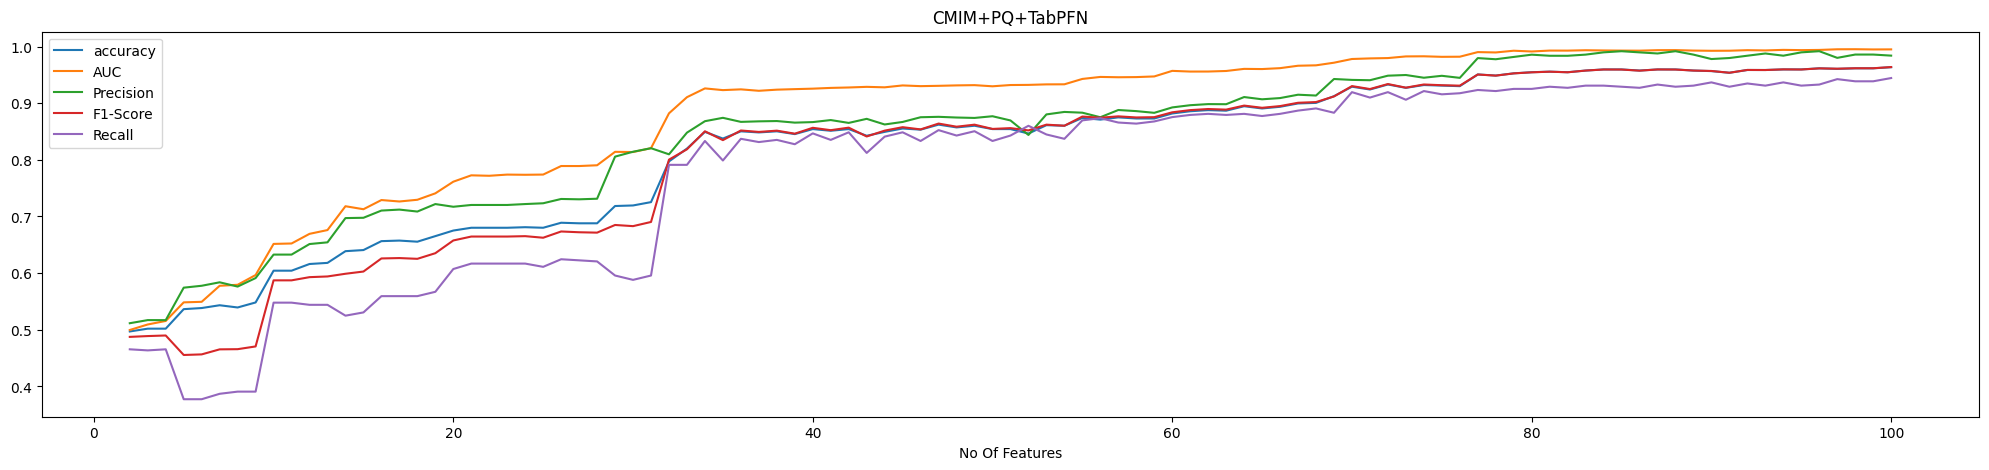

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(accuracy_tabPFN, label="accuracy")
plt.plot(auc_tabPFN, label="AUC")
plt.plot(Precision_tabPFN, label="Precision")
plt.plot(f1Score_tabPFN, label="F1-Score")
plt.plot(Recall_tabPFN , label="Recall")

plt.title("CMIM+PQ+TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("")
plt.legend()
plt.show()

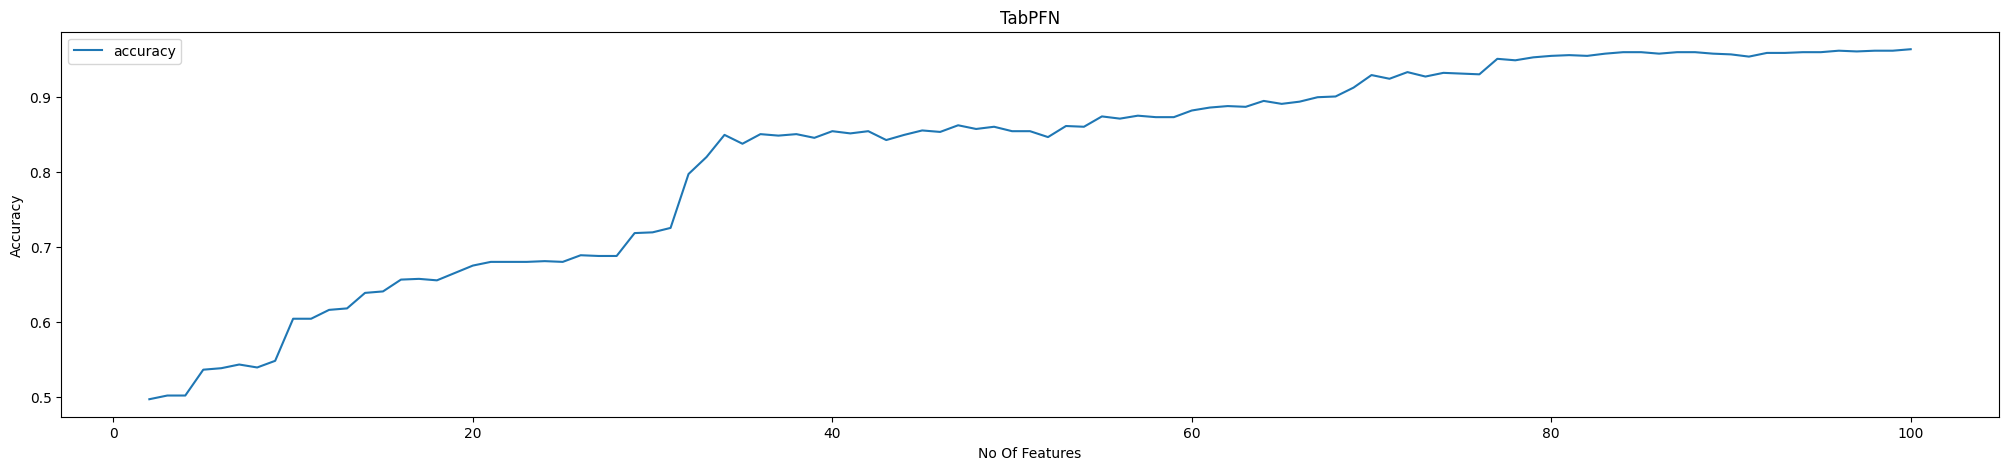

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(accuracy_tabPFN, label="accuracy")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

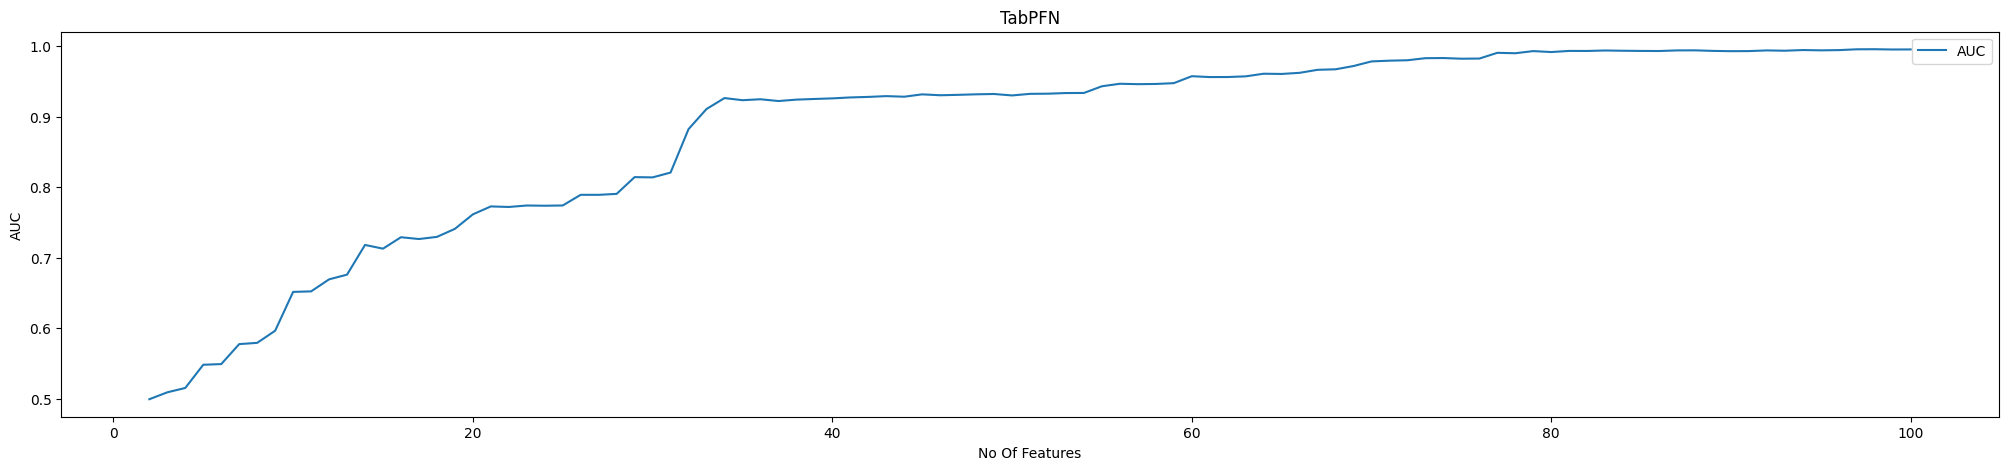

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(auc_tabPFN, label="AUC")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("AUC")
plt.legend()
plt.show()

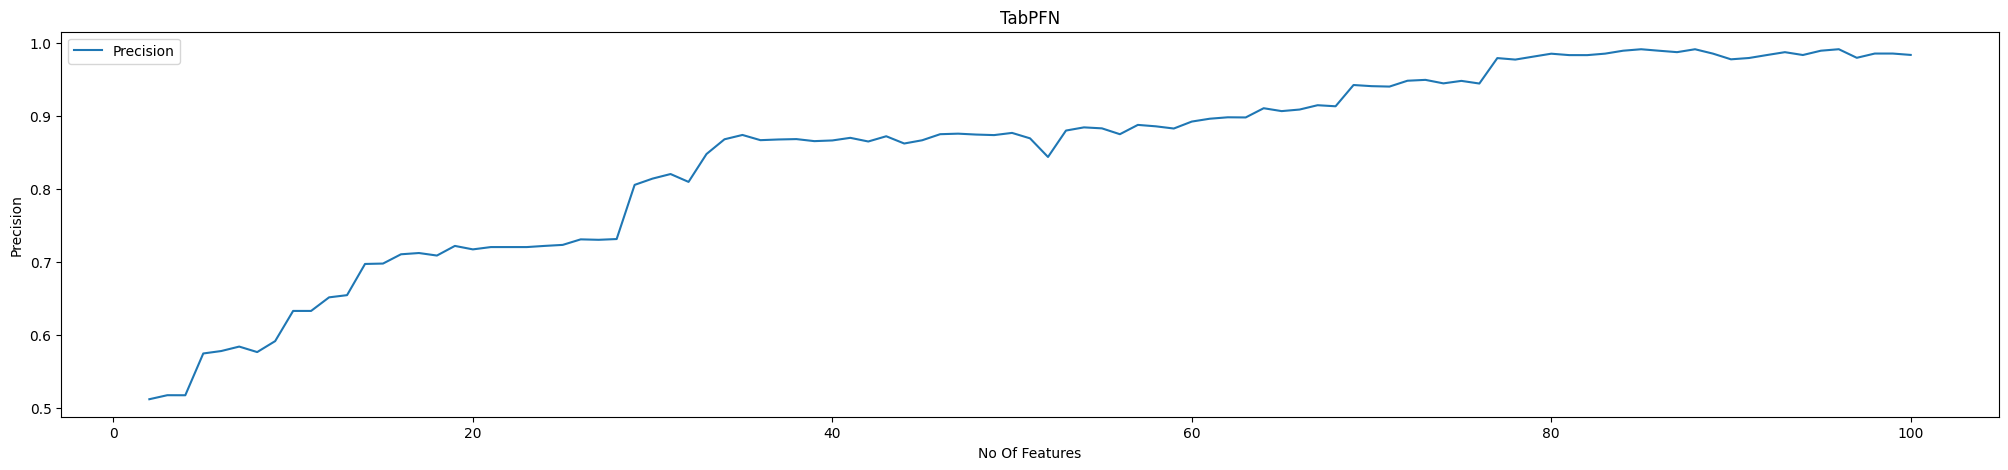

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(Precision_tabPFN, label="Precision")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("Precision")
plt.legend()
plt.show()

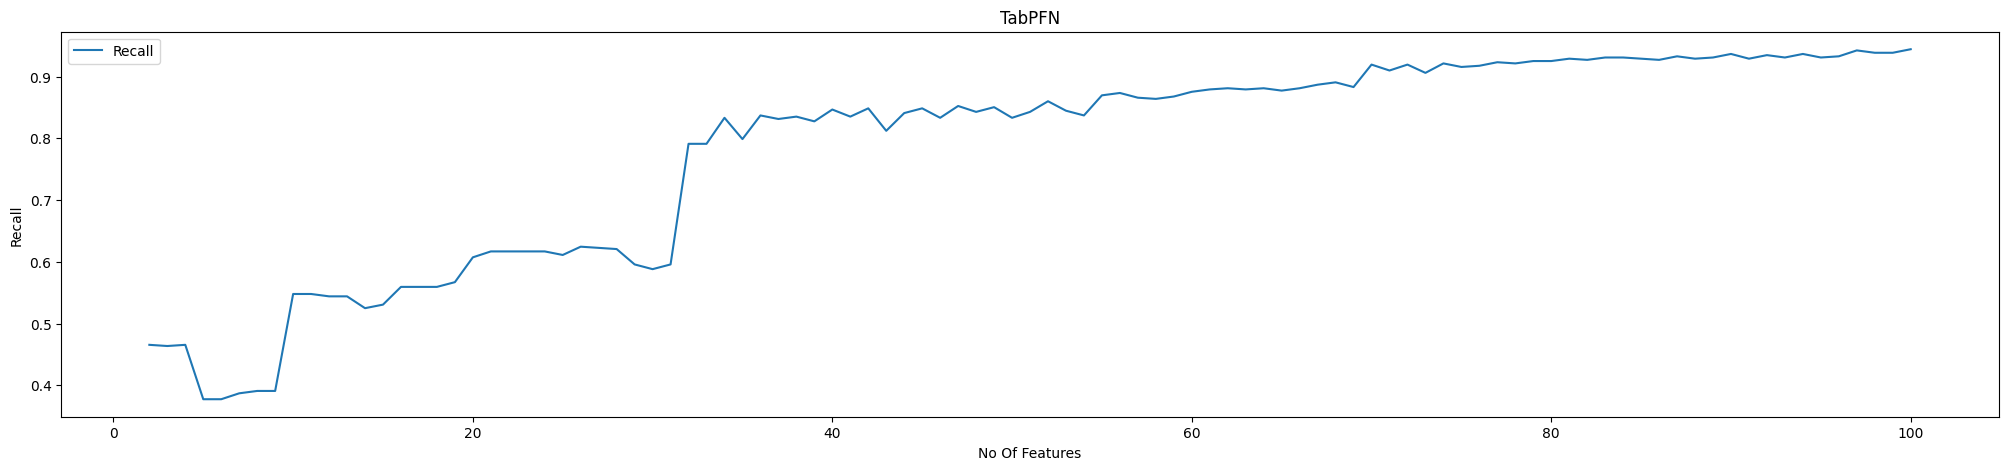

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(Recall_tabPFN , label="Recall")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("Recall")
plt.legend()
plt.show()

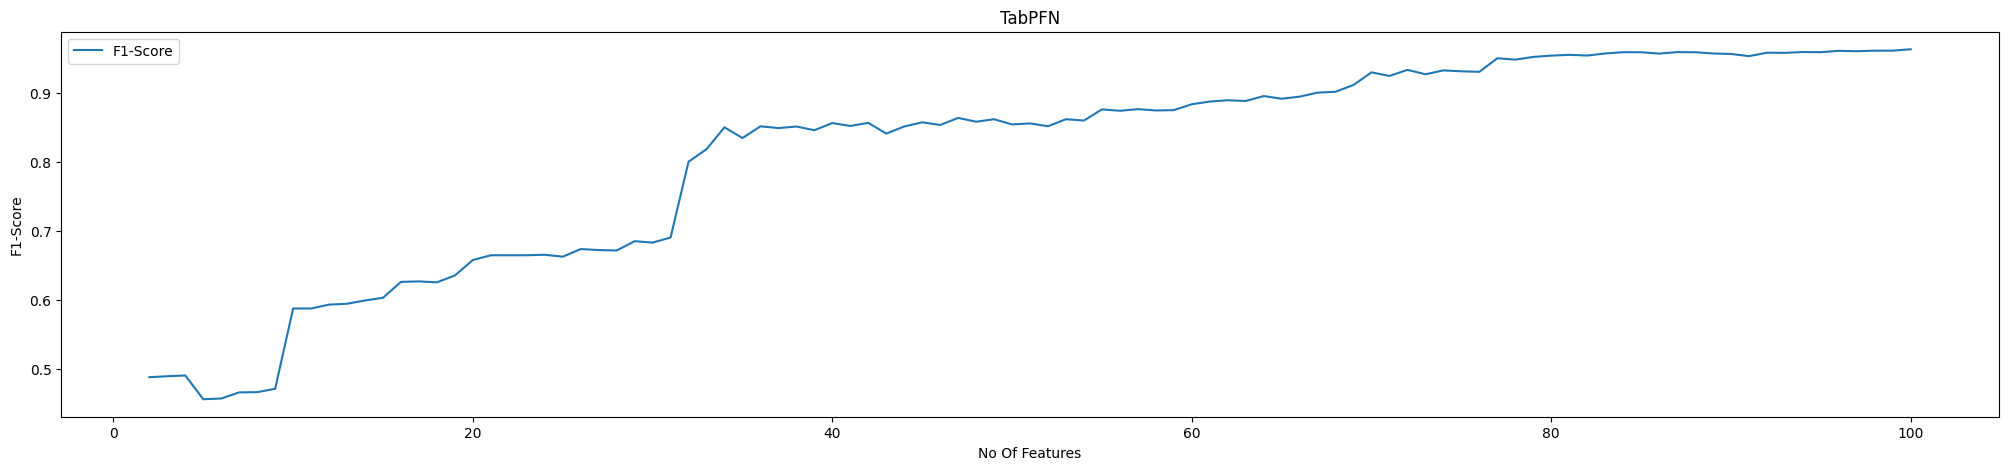

In [ ]:
plt.figure(figsize=(25,5))
plt.plot(f1Score_tabPFN, label="F1-Score")

plt.title("TabPFN")
plt.xlabel("No Of Features")
plt.ylabel("F1-Score")
plt.legend()
plt.show()